In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})


In [64]:
df_raw = pd.read_csv('customer_churn_dataset.csv')

print(f"   Rows    : {df_raw.shape[0]:,}")
print(f"   Columns : {df_raw.shape[1]}")
print(f"   Fields  : {list(df_raw.columns)}")


   Rows    : 64,374
   Columns : 12
   Fields  : ['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']


In [65]:
df_raw.head(10)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
5,6,30,Male,41,14,10,10,Premium,Monthly,500,29,0
6,7,47,Female,37,15,9,28,Basic,Quarterly,574,14,1
7,8,54,Female,36,11,0,18,Standard,Monthly,323,16,0
8,9,36,Male,20,5,10,8,Basic,Monthly,687,8,0
9,10,65,Male,8,4,2,23,Basic,Annual,995,10,0


In [66]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [67]:
df_raw.describe()


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [68]:
df = df_raw.copy()

print("Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "  None found")

dups = df.duplicated().sum()
print(f"\nDuplicate Rows: {dups}")
if dups > 0:
    df.drop_duplicates(inplace=True)
    print(f"  Removed {dups} duplicates")

df.drop(columns=['CustomerID'], inplace=True)
print(f"\nDropped 'CustomerID' column")

num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'Churn']
for col in num_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  Filled {col} nulls with median")

cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"  Filled {col} nulls with mode")

print(f"   Final shape     : {df.shape}")
print(f"   Missing values  : {df.isnull().sum().sum()}")


Missing Values:
  None found

Duplicate Rows: 0

Dropped 'CustomerID' column
   Final shape     : (64374, 11)
   Missing values  : 0


In [69]:
print("Churn Distribution:")
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f"\nChurn Rate : {df['Churn'].mean()*100:.1f}%")
print(f"Stayed     : {churn_counts[0]:,} ({churn_counts[0]/len(df)*100:.1f}%)")
print(f"Churned    : {churn_counts[1]:,} ({churn_counts[1]/len(df)*100:.1f}%)")


Churn Distribution:
Churn
0    33881
1    30493
Name: count, dtype: int64

Churn Rate : 47.4%
Stayed     : 33,881 (52.6%)
Churned    : 30,493 (47.4%)


In [70]:
print("Outlier Check (IQR Method):")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col:<20} : {outliers:>5} outliers  (Q1={Q1:.0f}, Q3={Q3:.0f})")
print("\n  Outliers retained — extreme values carry churn signal.")


Outlier Check (IQR Method):
  Age                  :     0 outliers  (Q1=30, Q3=54)
  Tenure               :     0 outliers  (Q1=18, Q3=47)
  Usage Frequency      :     0 outliers  (Q1=7, Q3=23)
  Support Calls        :     0 outliers  (Q1=3, Q3=8)
  Payment Delay        :     0 outliers  (Q1=10, Q3=25)
  Total Spend          :     0 outliers  (Q1=313, Q3=768)
  Last Interaction     :     0 outliers  (Q1=8, Q3=23)

  Outliers retained — extreme values carry churn signal.


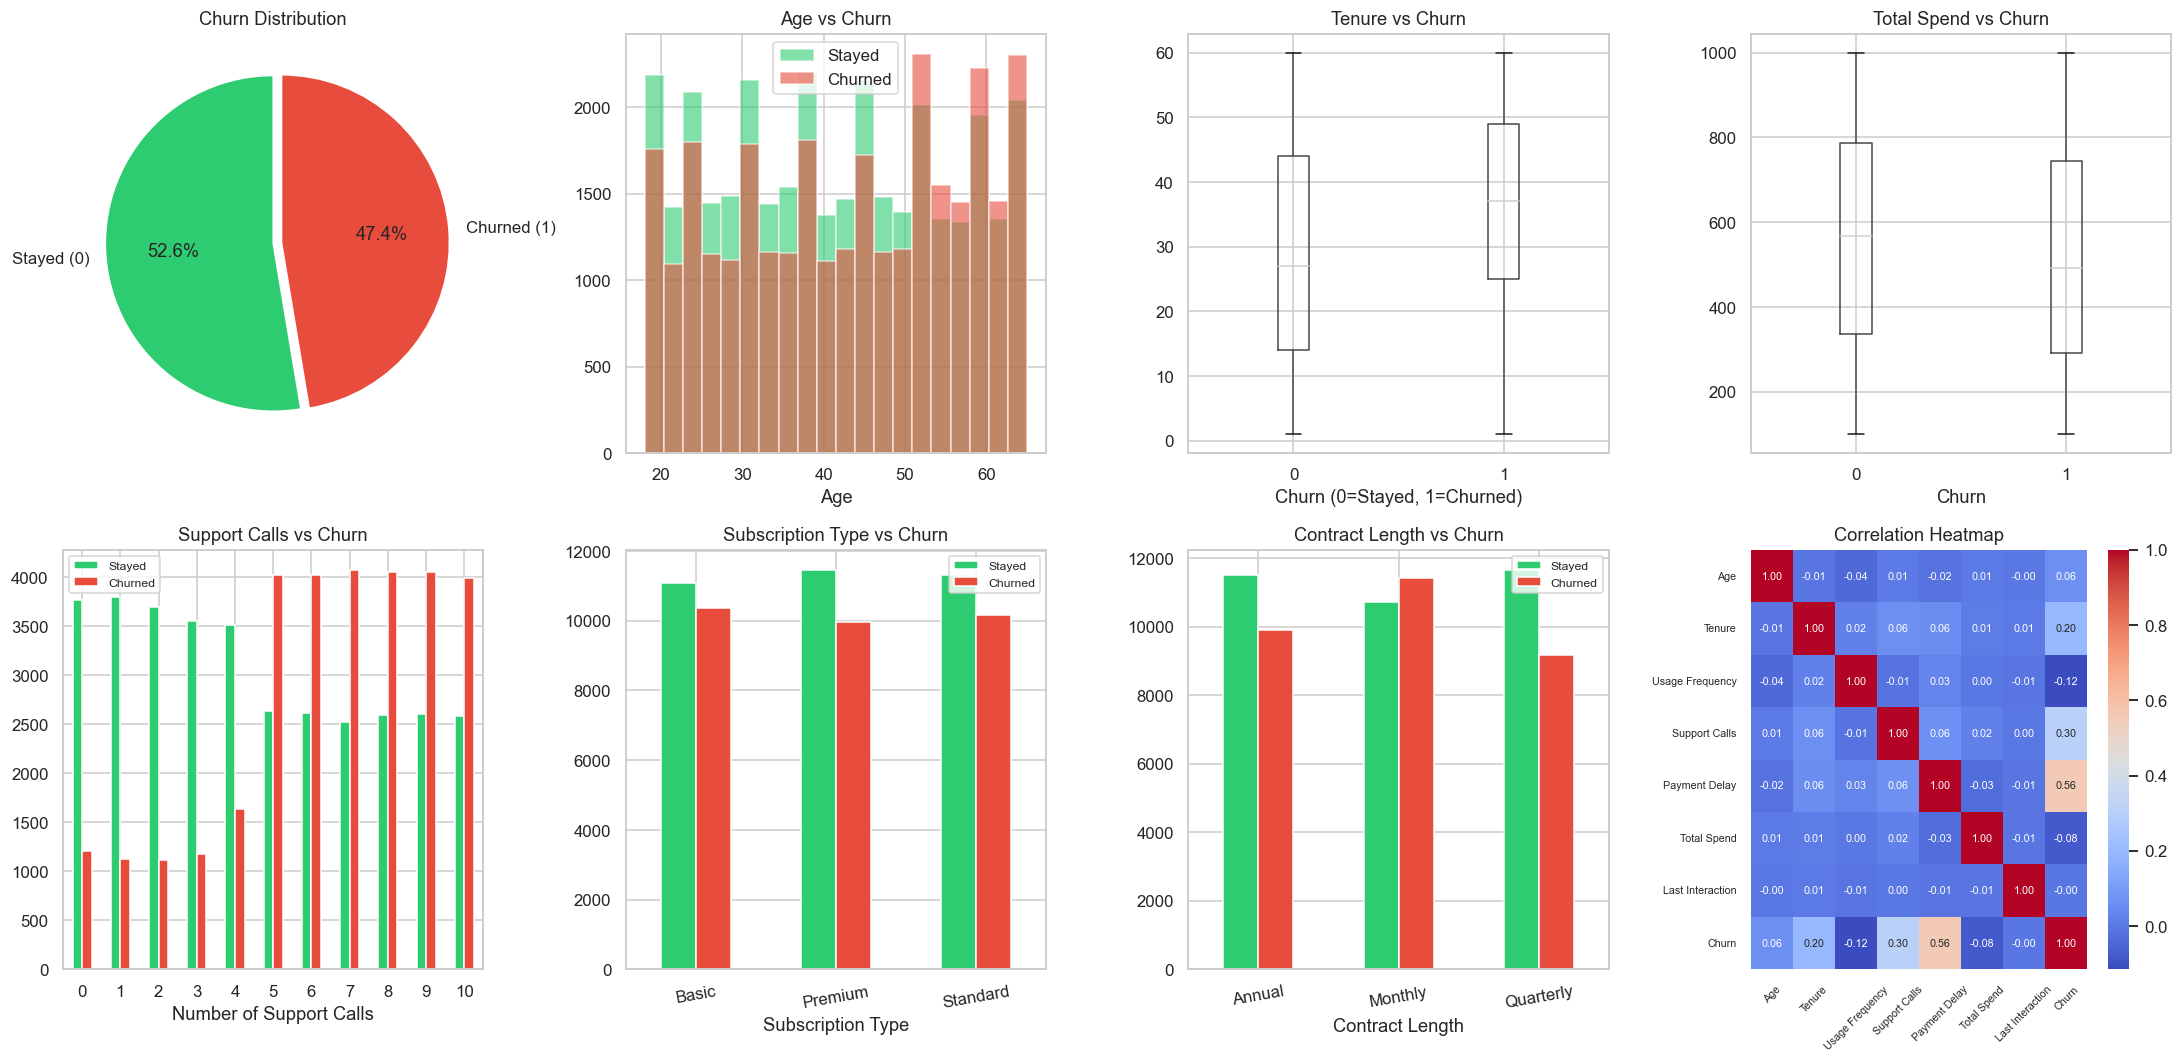

EDA saved to eda_plots.png


In [71]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Customer Churn – Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.01)

counts = df['Churn'].value_counts()
axes[0,0].pie(counts, labels=['Stayed (0)', 'Churned (1)'],
              autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'],
              startangle=90, explode=[0, 0.05])
axes[0,0].set_title('Churn Distribution')

for label, grp in df.groupby('Churn'):
    axes[0,1].hist(grp['Age'], alpha=0.6, bins=20,
                   label='Churned' if label == 1 else 'Stayed', color='#e74c3c' if label==1 else '#2ecc71')
axes[0,1].set_title('Age vs Churn')
axes[0,1].set_xlabel('Age'); axes[0,1].legend()

df.boxplot(column='Tenure', by='Churn', ax=axes[0,2])
plt.sca(axes[0,2]); plt.title('Tenure vs Churn'); plt.suptitle('')
axes[0,2].set_xlabel('Churn (0=Stayed, 1=Churned)')

df.boxplot(column='Total Spend', by='Churn', ax=axes[0,3])
plt.sca(axes[0,3]); plt.title('Total Spend vs Churn'); plt.suptitle('')
axes[0,3].set_xlabel('Churn')

sc_churn = df.groupby(['Support Calls','Churn']).size().unstack(fill_value=0)
sc_churn.plot(kind='bar', ax=axes[1,0], color=['#2ecc71','#e74c3c'])
axes[1,0].set_title('Support Calls vs Churn')
axes[1,0].set_xlabel('Number of Support Calls')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].legend(['Stayed','Churned'], fontsize=8)

st_churn = df.groupby(['Subscription Type','Churn']).size().unstack(fill_value=0)
st_churn.plot(kind='bar', ax=axes[1,1], color=['#2ecc71','#e74c3c'])
axes[1,1].set_title('Subscription Type vs Churn')
axes[1,1].tick_params(axis='x', rotation=10)
axes[1,1].legend(['Stayed','Churned'], fontsize=8)

cl_churn = df.groupby(['Contract Length','Churn']).size().unstack(fill_value=0)
cl_churn.plot(kind='bar', ax=axes[1,2], color=['#2ecc71','#e74c3c'])
axes[1,2].set_title('Contract Length vs Churn')
axes[1,2].tick_params(axis='x', rotation=10)
axes[1,2].legend(['Stayed','Churned'], fontsize=8)

corr = df[['Age','Tenure','Usage Frequency','Support Calls',
           'Payment Delay','Total Spend','Last Interaction','Churn']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,3],
            annot_kws={'size': 7})
axes[1,3].set_title('Correlation Heatmap')
axes[1,3].tick_params(axis='x', rotation=45, labelsize=7)
axes[1,3].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig('eda_plots.png', bbox_inches='tight')
plt.show()
print("EDA saved to eda_plots.png")


In [72]:
df_encoded = df.copy()

df_encoded['Gender'] = df_encoded['Gender'].map({'Female': 0, 'Male': 1})
print("Gender encoded  : Female=0, Male=1")

sub_map = {'Basic': 1, 'Standard': 2, 'Premium': 3}
df_encoded['Subscription Type'] = df_encoded['Subscription Type'].map(sub_map)
print("Subscription Type encoded : Basic=1, Standard=2, Premium=3")

contract_map = {'Monthly': 1, 'Quarterly': 2, 'Annual': 3}
df_encoded['Contract Length'] = df_encoded['Contract Length'].map(contract_map)
print("Contract Length encoded   : Monthly=1, Quarterly=2, Annual=3")

print(f"\nNull values after encoding: {df_encoded.isnull().sum().sum()}")
print(f"\nAll column dtypes after encoding:")
print(df_encoded.dtypes)


Gender encoded  : Female=0, Male=1
Subscription Type encoded : Basic=1, Standard=2, Premium=3
Contract Length encoded   : Monthly=1, Quarterly=2, Annual=3

Null values after encoding: 0

All column dtypes after encoding:
Age                  int64
Gender               int64
Tenure               int64
Usage Frequency      int64
Support Calls        int64
Payment Delay        int64
Subscription Type    int64
Contract Length      int64
Total Spend          int64
Last Interaction     int64
Churn                int64
dtype: object


In [73]:
df_encoded.head(5)


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,0,25,14,4,27,1,1,598,9,1
1,41,0,28,28,7,13,2,1,584,20,0
2,47,1,27,10,2,29,3,3,757,21,0
3,35,1,9,12,5,17,3,2,232,18,0
4,53,0,58,24,9,2,2,3,533,18,0


In [74]:
feature_cols = ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
                'Payment Delay', 'Subscription Type', 'Contract Length',
                'Total Spend', 'Last Interaction']

X = df_encoded[feature_cols]
y = df_encoded['Churn']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Features used    : {feature_cols}")
print(f"Training samples : {len(X_train):,}")
print(f"Testing  samples : {len(X_test):,}")
print(f"Churn in test set: {y_test.sum():,} / {len(y_test):,} ({y_test.mean()*100:.1f}%)")


Features used    : ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']
Training samples : 51,499
Testing  samples : 12,875
Churn in test set: 6,099 / 12,875 (47.4%)


In [75]:
lr = LogisticRegression(random_state=42, max_iter=1000, C=1.0)
lr.fit(X_train, y_train)

y_pred_lr  = lr.predict(X_test)
y_prob_lr  = lr.predict_proba(X_test)[:, 1]

acc_lr  = accuracy_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_prob_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
cv_lr   = cross_val_score(lr, X_scaled, y, cv=5, scoring='accuracy').mean()

print("ALGORITHM: 1 — LOGISTIC REGRESSION:")
print(f"  Accuracy         : {acc_lr*100:.2f}%")
print(f"  ROC-AUC          : {auc_lr:.4f}")
print(f"  F1-Score         : {f1_lr:.4f}")
print(f"  Precision        : {prec_lr:.4f}")
print(f"  Recall           : {rec_lr:.4f}")
print(f"  5-Fold CV Acc    : {cv_lr*100:.2f}%")
print()
print(classification_report(y_test, y_pred_lr, target_names=['Stayed', 'Churned']))


ALGORITHM: 1 — LOGISTIC REGRESSION:
  Accuracy         : 82.55%
  ROC-AUC          : 0.9023
  F1-Score         : 0.8171
  Precision        : 0.8114
  Recall           : 0.8228
  5-Fold CV Acc    : 82.66%

              precision    recall  f1-score   support

      Stayed       0.84      0.83      0.83      6776
     Churned       0.81      0.82      0.82      6099

    accuracy                           0.83     12875
   macro avg       0.82      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875



In [76]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                             min_samples_split=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_prob_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
cv_rf   = cross_val_score(rf, X_scaled, y, cv=5, scoring='accuracy').mean()

print("ALGORITHM: 2 — RANDOM FOREST:")
print(f"  Accuracy         : {acc_rf*100:.2f}%")
print(f"  ROC-AUC          : {auc_rf:.4f}")
print(f"  F1-Score         : {f1_rf:.4f}")
print(f"  Precision        : {prec_rf:.4f}")
print(f"  Recall           : {rec_rf:.4f}")
print(f"  5-Fold CV Acc    : {cv_rf*100:.2f}%")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Churned']))


ALGORITHM: 2 — RANDOM FOREST:
  Accuracy         : 99.84%
  ROC-AUC          : 1.0000
  F1-Score         : 0.9983
  Precision        : 0.9992
  Recall           : 0.9974
  5-Fold CV Acc    : 99.91%

              precision    recall  f1-score   support

      Stayed       1.00      1.00      1.00      6776
     Churned       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



In [83]:
summary = pd.DataFrame({
    'Algorithm'    : ['Logistic Regression', 'Random Forest'],
    'Accuracy (%)'  : [round(acc_lr*100, 2),  round(acc_rf*100, 2)],
    'ROC-AUC'      : [round(auc_lr, 4),       round(auc_rf, 4)],
    'F1-Score'     : [round(f1_lr, 4),        round(f1_rf, 4)],
    'Precision'    : [round(prec_lr, 4),      round(prec_rf, 4)],
    'Recall'       : [round(rec_lr, 4),       round(rec_rf, 4)],
    'CV Acc (%)'   : [round(cv_lr*100, 2),    round(cv_rf*100, 2)],
})
print("MODEL ACCURACY COMPARISON TABLE:")
print(summary.to_string(index=False))
winner = 'Random Forest' if acc_rf >= acc_lr else 'Logistic Regression'
print(f"\n Better Model (by Accuracy): {winner}")


MODEL ACCURACY COMPARISON TABLE:
          Algorithm  Accuracy (%)  ROC-AUC  F1-Score  Precision  Recall  CV Acc (%)
Logistic Regression         82.55   0.9023    0.8171     0.8114  0.8228       82.66
      Random Forest         99.84   1.0000    0.9983     0.9992  0.9974       99.91

 Better Model (by Accuracy): Random Forest


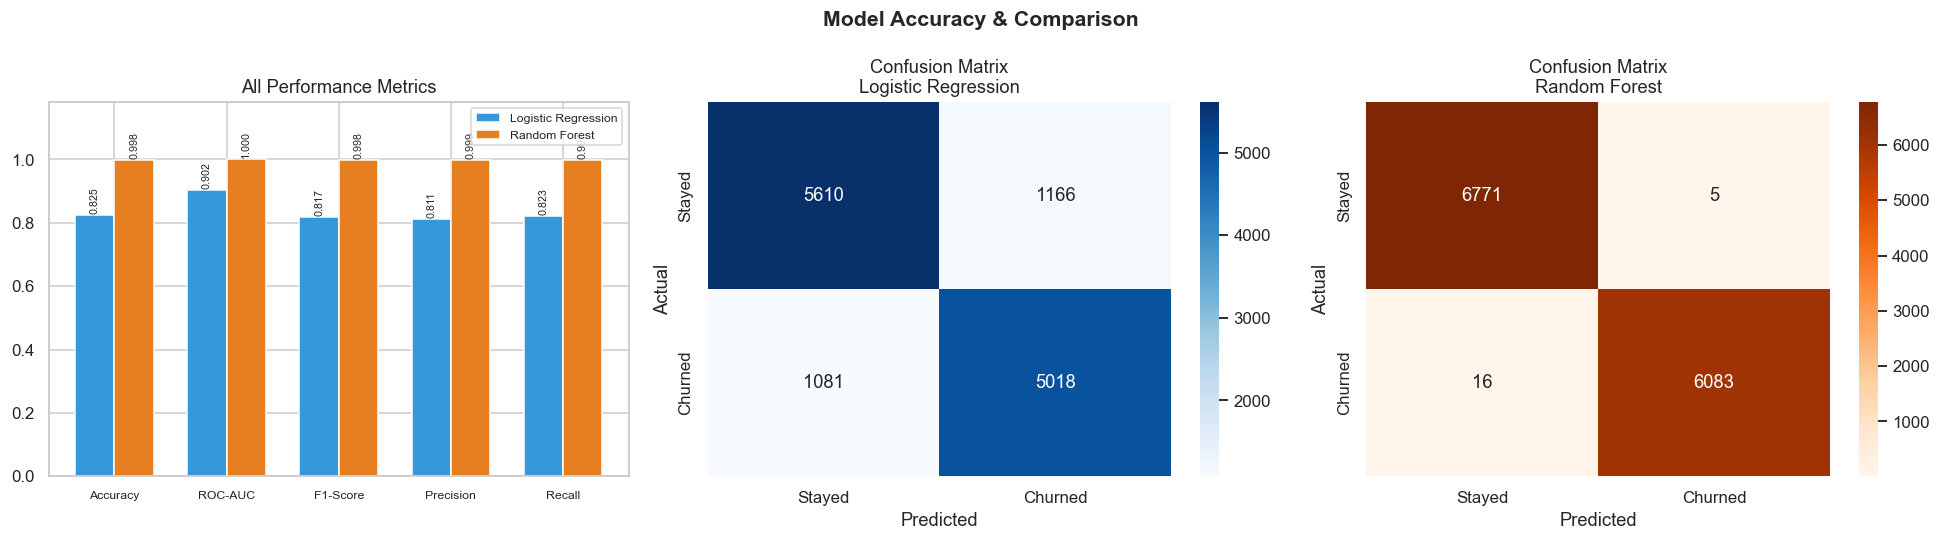

Saved to model_comparison.png


In [84]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Accuracy & Comparison', fontsize=14, fontweight='bold')

metrics = ['Accuracy', 'ROC-AUC', 'F1-Score', 'Precision', 'Recall']
lr_vals = [acc_lr, auc_lr, f1_lr, prec_lr, rec_lr]
rf_vals = [acc_rf, auc_rf, f1_rf, prec_rf, rec_rf]
x = np.arange(len(metrics)); w = 0.35

b1 = axes[0].bar(x - w/2, lr_vals, w, label='Logistic Regression', color='#3498db')
b2 = axes[0].bar(x + w/2, rf_vals, w, label='Random Forest',       color='#e67e22')
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics, fontsize=8)
axes[0].set_ylim(0, 1.18); axes[0].set_title('All Performance Metrics')
axes[0].legend(fontsize=8)
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=7, rotation=90)

sns.heatmap(confusion_matrix(y_test, y_pred_lr),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'], ax=axes[1])
axes[1].set_title('Confusion Matrix\nLogistic Regression')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'], ax=axes[2])
axes[2].set_title('Confusion Matrix\nRandom Forest')
axes[2].set_ylabel('Actual'); axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()
print("Saved to model_comparison.png")


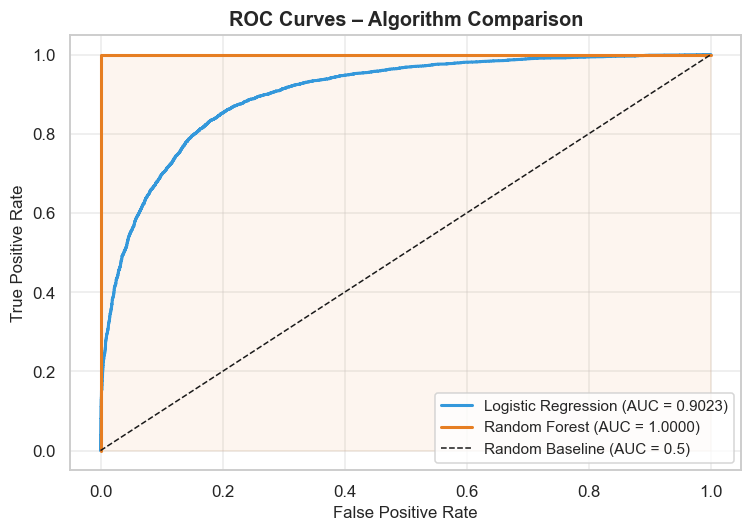

Saved to roc_curves.png


In [85]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, yp, color in [
        ('Logistic Regression', y_prob_lr, '#3498db'),
        ('Random Forest',       y_prob_rf, '#e67e22')]:
    fpr, tpr, _ = roc_curve(y_test, yp)
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f'{name} (AUC = {roc_auc_score(y_test, yp):.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Baseline (AUC = 0.5)')
ax.fill_between(*roc_curve(y_test, y_prob_rf)[:2], alpha=0.07, color='#e67e22')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves – Algorithm Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()
print("Saved to roc_curves.png")


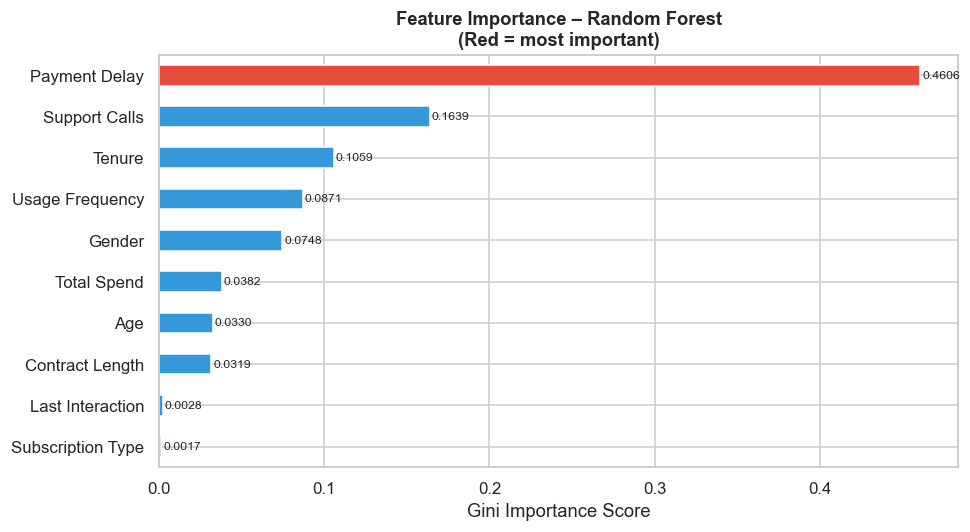


Top 5 Features:
Payment Delay      0.460603
Support Calls      0.163934
Tenure             0.105889
Usage Frequency    0.087150
Gender             0.074825
dtype: float64


In [86]:
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if v == top.max() else '#3498db' for v in top.values]
top.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Importance – Random Forest\n(Red = most important)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Gini Importance Score')
for i, v in enumerate(top.values):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print("\nTop 5 Features:")
print(importances.sort_values(ascending=False).head())


In [87]:
def rule_based_churn(age, tenure, usage_freq, support_calls,
                     payment_delay, subscription_type,
                     contract_length, total_spend, last_interaction):

    score, reasons = 0, []

    if support_calls >= 5:
        score += 4; reasons.append("Support calls ≥5 (+4)")
    elif support_calls >= 3:
        score += 2; reasons.append("Support calls ≥3 (+2)")

    if payment_delay >= 20:
        score += 3; reasons.append("Payment delay ≥20 days (+3)")
    elif payment_delay >= 10:
        score += 1; reasons.append("Payment delay ≥10 days (+1)")

    if contract_length == 'Monthly':
        score += 3; reasons.append("Monthly contract (+3)")
    elif contract_length == 'Annual':
        score -= 3; reasons.append("Annual contract (-3)")

    if subscription_type == 'Basic':
        score += 2; reasons.append("Basic subscription (+2)")
    elif subscription_type == 'Premium':
        score -= 2; reasons.append("Premium subscription (-2)")

    if tenure <= 6:
        score += 2; reasons.append("New customer ≤6 months (+2)")
    elif tenure >= 36:
        score -= 1; reasons.append("Long-term customer ≥36 months (-1)")

    if usage_freq <= 5:
        score += 2; reasons.append("Low usage frequency ≤5 (+2)")

    if support_calls == 0 and tenure > 24:
        score -= 2; reasons.append("Zero support calls + long tenure (-2)")

    if last_interaction >= 25:
        score += 1; reasons.append("Last interaction ≥25 days (+1)")

    prediction = 1 if score >= 5 else 0
    label = "CHURN" if prediction else "STAY"
    return prediction, label, score, reasons

df_rule = df.reset_index(drop=True).copy()

rule_results = df_rule.apply(
    lambda r: rule_based_churn(
        r['Age'], r['Tenure'], r['Usage Frequency'], r['Support Calls'],
        r['Payment Delay'], r['Subscription Type'],
        r['Contract Length'], r['Total Spend'], r['Last Interaction']),
    axis=1, result_type='expand')
rule_results.columns = ['Rule_Pred', 'Rule_Label', 'Risk_Score', 'Reasons']
df_rule = pd.concat([df_rule, rule_results], axis=1)

rule_acc  = accuracy_score(df_rule['Churn'], df_rule['Rule_Pred'])
rule_f1   = f1_score(df_rule['Churn'],       df_rule['Rule_Pred'])
rule_prec = precision_score(df_rule['Churn'], df_rule['Rule_Pred'])
rule_rec  = recall_score(df_rule['Churn'],    df_rule['Rule_Pred'])

print(f"Rule-Based Accuracy  : {rule_acc*100:.2f}%")
print(f"Rule-Based F1-Score  : {rule_f1:.4f}")
print(f"Rule-Based Precision : {rule_prec:.4f}")
print(f"Rule-Based Recall    : {rule_rec:.4f}")
print(f"\nPrediction counts:")
print(df_rule['Rule_Label'].value_counts())


Rule-Based Accuracy  : 64.19%
Rule-Based F1-Score  : 0.6430
Rule-Based Precision : 0.6092
Rule-Based Recall    : 0.6809

Prediction counts:
Rule_Label
CHURN    34085
STAY     30289
Name: count, dtype: int64


In [88]:
print("\nSample Predictions (15 rows):")
cols_show = ['Age','Tenure','Support Calls','Payment Delay',
             'Subscription Type','Contract Length','Churn','Rule_Label','Risk_Score']
print(df_rule[cols_show].head(15).to_string(index=False))



Sample Predictions (15 rows):
 Age  Tenure  Support Calls  Payment Delay Subscription Type Contract Length  Churn Rule_Label  Risk_Score
  22      25              4             27             Basic         Monthly      1      CHURN          10
  41      28              7             13          Standard         Monthly      0      CHURN           8
  47      27              2             29           Premium          Annual      0       STAY          -2
  35       9              5             17           Premium       Quarterly      0       STAY           3
  53      58              9              2          Standard          Annual      0       STAY           0
  30      41             10             10           Premium         Monthly      0      CHURN           6
  47      37              9             28             Basic       Quarterly      1      CHURN           8
  54      36              0             18          Standard         Monthly      0       STAY           1
  36  